In [4]:
%env CUDA_VISIBLE_DEVICES = 5

env: CUDA_VISIBLE_DEVICES=5


In [17]:
from fetch_dataset_and_processing import find_train_val_files, find_test_files, ImageNet
from train_loop import train
from inference import predict, predict_one_sample, make_predictions
from visualizing import imshow, plot_train_set, plot_results

from resnet50 import IdentityBlock, ConvBlock, ResNet50
from resnet18_cnn import ResBlock, ResNet18

import torch
from sklearn.model_selection import train_test_split
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [3]:
! nvidia-smi

Thu Feb  2 11:26:57 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 520.56.06    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  Off  | 00000000:1A:00.0 Off |                  N/A |
| 26%   32C    P0    46W / 260W |      0MiB / 11264MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  Off  | 00000000:1B:00.0 Off |                  N/A |
| 26%   

In [9]:
device = 'cuda:0'

In [5]:
train_val_files, train_val_labels = find_train_val_files()
test_files, test_labels = find_test_files()

In [6]:
len(train_val_files), len(test_files)

(9103, 3791)

In [6]:
train_set, val_set, tr_labels, val_labels = train_test_split(train_val_files, train_val_labels, test_size=0.2, \
                                          stratify=train_val_labels)

In [7]:
train_dataset = ImageNet(train_set, tr_labels, 'train')
val_dataset = ImageNet(val_set, val_labels, 'val')
test_dataset = ImageNet(test_files, test_labels, 'test')

In [8]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

### ResNet 18

In [11]:
resnet = ResNet18(ResBlock).to(device)
resnet

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (linear): Linear(in_features=256, out_features=10, bias=True)
  (layer1): Sequential(
    (0): ResBlock(
      (conv_block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Identity()
    )
    (1): ResBlock(
      (conv_block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d

In [19]:
epochs = 10
opt = torch.optim.Adam(resnet.parameters(), lr=1e-4, weight_decay=1e-5)
loss_fn = nn.CrossEntropyLoss()
path = 'Resnet_with_reg.pth'
name = 'resnet_with_reg'

In [20]:
losses_res, metrics_res = train(resnet, opt, loss_fn, epochs, train_loader, val_loader, name, path)

Epoch 0/9:


train iter:: 100%|██████████| 456/456 [00:50<00:00,  9.10it/s]


train Loss: 1.6710
train Accuracy: 0.4242


val iter:: 100%|██████████| 114/114 [00:08<00:00, 14.24it/s]


val Loss: 1.5370
val Accuracy: 0.4990
Epoch 1/9:


...

val Loss: 0.6891
val Accuracy: 0.7766
Epoch 9/9:


train iter:: 100%|██████████| 456/456 [00:41<00:00, 11.02it/s]


train Loss: 0.2452
train Accuracy: 0.9598


val iter:: 100%|██████████| 114/114 [00:06<00:00, 16.82it/s]

val Loss: 0.6914
val Accuracy: 0.7750


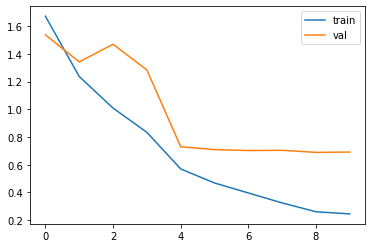

In [ ]:
plt.plot(losses_res['train'], label='train')
plt.plot(losses_res['val'], label='val')
plt.legend()
plt.show()

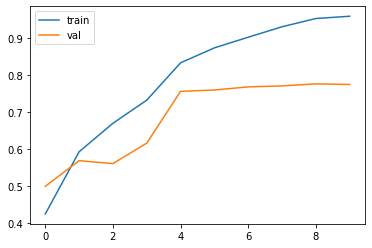

In [ ]:
plt.plot(metrics_res['train'], label='train')
plt.plot(metrics_res['val'], label='val')
plt.legend()
plt.show()

### Inference

In [24]:
predictions_resnet = make_predictions(resnet, imgs_test)

In [25]:
accuracy_score(predictions_resnet, actual_labels_test)

0.7728831442891058

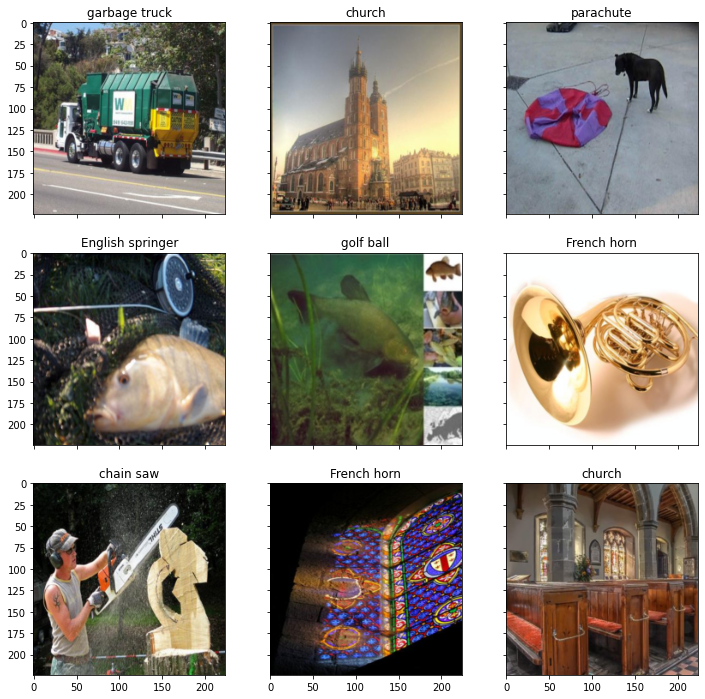

In [171]:
plot_results(resnet, test_dataset)